# Свой поисковый эмбеддер под домен и LLM-судья

Мотивация бытовая: несколько тысяч сохранённых статей и заметок на русском, в которых ничего
нельзя найти. Ctrl+F ищет точное слово, а помнишь обычно смысл, а не формулировку. Готовый
эмбеддер помогает, но заметно мимо, и понятно почему: модели общего назначения отвечают на
вопрос «похожи ли эти два текста», а поиску нужен другой — «есть ли в этом тексте ответ».
Значит, модель надо дообучать под задачу.

Тут стена: для дообучения нужны пары «запрос — правильный документ», а их нет, и размечать
десять тысяч пар руками никто не станет. Напрашивается ответ — пусть размечает языковая
модель (LLM-as-a-judge). Так делают часто, а вот насколько такой судья согласен с живым
асессором, публикуют редко.

Отсюда два вопроса проекта:

1. **сколько на самом деле даёт дообучение под домен;**
2. **можно ли доверить разметку модели** — с числом согласия на руках.

Проверять это на личных заметках нельзя: там нет разметки, а значит, нечем мерить. Поэтому
стенд — русская часть MIRACL. Задача та же (вопрос на естественном языке → нужный абзац),
но с человеческими метками, причём с обеих сторон: и релевантные пары, и проверенно
нерелевантные. На первых модель учится, на вторых ловим судью за руку.

**Содержание.** 1. Данные · 2. Метрики · 3. Бейзлайны · 4. Майнинг сложных негативов ·
5. Дообучение эмбеддера · 6. Реранкер · 7. ANN-индекс · 8. LLM-судья ·
9. Итоговая таблица · 10. Разбор ошибок · 11. Выводы

Всё считалось на одном MacBook (Apple Silicon, 16 ГБ). Числа из литературы помечены
**[ОЦЕНКА]**.

**Как устроен ноутбук.** Всё, что требует GPU/MPS или локальной LLM, выключено флагами
в первой ячейке кода; эти шаги пишут результаты в `results/`, и дальше ноутбук читает только
оттуда. С выключенными флагами ноутбук за пару минут воспроизводит все таблицы и графики;
нужен только собранный корпус (раздел 1 скачивает и собирает его сам, на CPU).

In [1]:
import gzip
import hashlib
import json
import math
import os
import random
import re
import time
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd

SEED = 42

# Тяжёлые шаги. Всё, что они считают, уже лежит в results/ — включать нужно,
# только чтобы пересчитать. Включать по порядку: каждый шаг опирается на предыдущий.
RUN_SEARCH = False    # BM25 и готовые энкодеры по корпусу + майнинг негативов (GPU/MPS, ~20 мин)
RUN_TRAIN = False     # 13 вариантов дообучения rubert-tiny2 (GPU/MPS, ~1.5 часа)
RUN_RERANKER = False  # кросс-энкодер-реранкер и проверка, почему он не учится (GPU/MPS, ~1 час)
RUN_ANN = False       # HNSW-индекс и замер задержки (нужна модель из RUN_TRAIN)
RUN_JUDGE = False     # LLM-судья: qwen2.5:7b через локальный Ollama (~1 час)

DATA, MODELS, RES, FIG = Path("data"), Path("models"), Path("results"), Path("figures")
RAW, MINI, CACHE = DATA / "raw", DATA / "mini", DATA / "cache"
for d in (RAW, MINI, CACHE, MODELS, RES, FIG):
    d.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 90)


def load(name):
    return json.loads((RES / f"{name}.json").read_text(encoding="utf-8"))


def dump(obj, name):
    (RES / f"{name}.json").write_text(json.dumps(obj, ensure_ascii=False, indent=1),
                                      encoding="utf-8")


def load_or(name, default):
    return load(name) if (RES / f"{name}.json").exists() else default


def get_device():
    import torch
    if torch.backends.mps.is_available():
        return "mps"
    return "cuda" if torch.cuda.is_available() else "cpu"


def free_memory():
    """Кеш ускорителя сам не отпускается между моделями в одном процессе: без явного сброса
    за серию обучений он дорастает до десятка гигабайт, и машина уходит в своп."""
    import gc
    import torch
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()

In [2]:
import matplotlib.pyplot as plt

# Единый вид графиков: светлый фон, тонкие линии, приглушённая сетка.
INK, INK_2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 10, "axes.labelsize": 9.5, "xtick.color": INK_2, "ytick.color": INK_2,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID,
    "grid.linewidth": 0.6, "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2, "lines.markersize": 7,
    "figure.dpi": 110, "savefig.dpi": 160, "savefig.bbox": "tight",
})


def save(fig, name):
    """Сохраняет график в figures/ — оттуда их берёт README."""
    fig.savefig(FIG / f"{name}.png")

## 1. Данные

**MIRACL** ([arXiv:2210.09984](https://arxiv.org/abs/2210.09984)): носители языка
писали вопросы к статьям Википедии, асессоры размечали, содержит ли пассаж ответ.
Разметка бинарная; таблица «запрос → документ → оценка» называется **qrels**.
Лицензия — Apache 2.0.

Нерелевантные пары там не случайные: документ попадал на разметку, если его достала
какая-то поисковая система. То есть это близкие по теме документы, которые человек
посмотрел и забраковал, — материал и для калибровки судьи, и для экспериментов с
негативами.

Скачиваются вопросы, разметка и полный русский корпус (20 файлов, ~1.5 ГБ) — только если
мини-корпус ещё не собран.

In [3]:
from huggingface_hub import hf_hub_download

MIRACL_DIR = RAW / "miracl-v1.0-ru"
CORPUS_DIR = RAW / "miracl-corpus-v1.0-ru"

if not (MINI / "splits.json").exists():
    for split in ("train", "dev"):
        for kind in ("topics", "qrels"):
            f = f"miracl-v1.0-ru/{kind}/{kind}.miracl-v1.0-ru-{split}.tsv"
            if not (RAW / f).exists():
                hf_hub_download("miracl/miracl", f, repo_type="dataset", local_dir=RAW)
    for i in range(20):
        f = f"miracl-corpus-v1.0-ru/docs-{i}.jsonl.gz"
        if not (RAW / f).exists():
            hf_hub_download("miracl/miracl-corpus", f, repo_type="dataset", local_dir=RAW)

### Как собран мини-корпус

Полный корпус — 9.5 миллиона пассажей, на ноутбуке не живёт. Берём **все** документы из
разметки (иначе у запроса пропадут правильные ответы) и добираем случайных дистракторов
до 150 тысяч через **reservoir sampling** — выбор N случайных элементов за один проход
по потоку. Пассаж — это заголовок статьи плюс текст абзаца: заголовок почти всегда несёт
сущность, о которой спрашивают.

Три оговорки. **Абсолютные числа несравнимы с лидербордом** — корпус урезан в 64 раза,
сколько это стоит, в разделе 3. **Dev поделён на valid (300) и test:** всё подбирается на
valid, финальные числа считаются на test один раз. **MIRACL разводит train и dev по id
запроса, но не по тексту** — несколько dev-запросов слово в слово совпадают с train,
их выкидываем.

In [4]:
def load_topics(split):
    """qid -> текст запроса."""
    path = MIRACL_DIR / "topics" / f"topics.miracl-v1.0-ru-{split}.tsv"
    return dict(line.rstrip("\n").split("\t") for line in open(path, encoding="utf-8"))


def load_qrels(split):
    """qid -> {docid: rel}. Включает и rel=0 — размеченные человеком негативы."""
    out = {}
    for line in open(MIRACL_DIR / "qrels" / f"qrels.miracl-v1.0-ru-{split}.tsv", encoding="utf-8"):
        qid, _, docid, rel = line.rstrip("\n").split("\t")
        out.setdefault(qid, {})[docid] = int(rel)
    return out


def iter_corpus():
    for i in range(20):
        with gzip.open(CORPUS_DIR / f"docs-{i}.jsonl.gz", "rt", encoding="utf-8") as f:
            for line in f:
                yield json.loads(line)


def make_passage(title, text):
    title, text = (title or "").strip(), (text or "").strip()
    return f"{title}. {text}" if title else text


def norm_query(s):
    return re.sub(r"[^\w\s]", "", s.lower()).strip()


def build_mini_corpus(target_size=150_000, n_valid=300, seed=SEED):
    rng = random.Random(seed)
    topics = {s: load_topics(s) for s in ("train", "dev")}
    qrels = {s: load_qrels(s) for s in ("train", "dev")}

    dev_qids = sorted(topics["dev"])
    rng.shuffle(dev_qids)
    valid_qids, test_qids = sorted(dev_qids[:n_valid]), sorted(dev_qids[n_valid:])
    train_qids = sorted(topics["train"])

    # все документы из разметки (и rel=1, и rel=0) обязаны попасть в корпус
    required = {d for s in ("train", "dev") for m in qrels[s].values() for d in m}
    n_distractors = target_size - len(required)

    kept, reservoir, seen = {}, [], 0
    for doc in iter_corpus():                      # один проход, reservoir sampling
        if doc["docid"] in required:
            kept[doc["docid"]] = doc
            continue
        seen += 1
        if len(reservoir) < n_distractors:
            reservoir.append(doc)
        else:
            j = rng.randrange(seen)
            if j < n_distractors:
                reservoir[j] = doc

    docs = sorted(list(kept.values()) + reservoir, key=lambda d: d["docid"])
    with open(MINI / "corpus.jsonl", "w", encoding="utf-8") as f:
        for d in docs:
            f.write(json.dumps({"docid": d["docid"], "title": d.get("title", ""),
                                "passage": make_passage(d.get("title", ""), d["text"])},
                               ensure_ascii=False) + "\n")

    corpus_ids = {d["docid"] for d in docs}
    clean_qrels = {s: {q: {d: r for d, r in m.items() if d in corpus_ids}
                       for q, m in qrels[s].items()} for s in ("train", "dev")}
    all_topics = {**topics["train"], **topics["dev"]}

    # дословные дубли train-запросов в valid/test
    train_texts = {norm_query(all_topics[q]) for q in train_qids}
    dropped = {}
    for name, qids in (("valid", valid_qids), ("test", test_qids)):
        drop = [q for q in qids if norm_query(all_topics[q]) in train_texts]
        dropped[name] = [{"qid": q, "query": all_topics[q]} for q in drop]
        qids[:] = [q for q in qids if q not in set(drop)]

    splits = {"seed": seed, "target_size": target_size, "corpus_size": len(docs),
              "full_corpus_size": seen + len(kept), "n_judged_docs": len(kept),
              "n_distractors": len(reservoir), "train_qids": train_qids,
              "valid_qids": valid_qids, "test_qids": test_qids, "topics": all_topics,
              "qrels": clean_qrels, "dropped_duplicates": dropped}
    (MINI / "splits.json").write_text(json.dumps(splits, ensure_ascii=False, indent=2),
                                      encoding="utf-8")


if not (MINI / "splits.json").exists():
    build_mini_corpus()

SP = json.loads((MINI / "splits.json").read_text(encoding="utf-8"))
TOPICS, QRELS_TRAIN, QRELS_DEV = SP["topics"], SP["qrels"]["train"], SP["qrels"]["dev"]
TRAIN_QIDS = [q for q in SP["train_qids"] if any(r > 0 for r in QRELS_TRAIN.get(q, {}).values())]
DOCIDS, PASSAGES = [], []
for line in open(MINI / "corpus.jsonl", encoding="utf-8"):
    d = json.loads(line)
    DOCIDS.append(d["docid"])
    PASSAGES.append(d["passage"])
BY_ID = dict(zip(DOCIDS, PASSAGES))

In [5]:
print(f"полный корпус MIRACL-ru:   {SP['full_corpus_size']:,} пассажей")
print(f"мини-корпус:               {SP['corpus_size']:,} "
      f"({100 * SP['corpus_size'] / SP['full_corpus_size']:.2f}% от полного)")
print(f"   из разметки:            {SP['n_judged_docs']:,}")
print(f"   случайных дистракторов: {SP['n_distractors']:,}")
print(f"\nзапросов: train {len(SP['train_qids']):,} | "
      f"valid {len(SP['valid_qids']):,} | test {len(SP['test_qids']):,}")
for split, items in SP["dropped_duplicates"].items():
    print(f"\nвыкинуто из {split} как дубли train-запросов: {len(items)}")
    for it in items:
        print(f"    {it['query']}")

полный корпус MIRACL-ru:   9,543,918 пассажей
мини-корпус:               150,000 (1.57% от полного)
   из разметки:            41,007
   случайных дистракторов: 108,993

запросов: train 4,683 | valid 299 | test 947

выкинуто из valid как дубли train-запросов: 1
    Откуда пошла фраза: "В Багдаде все спокойно"?

выкинуто из test как дубли train-запросов: 5
    Когда началась Вели́кая Оте́чественная война́?
    Как звали верховного Бога викингов?
    По какому озеру проходила "Дорога жизни"?
    Когда пал "железный занавес"?
    Кто автор памятника «Рабо́чий и колхо́зница»?


In [6]:
ex_q = SP["test_qids"][7]
ex_gold = [d for d, r in QRELS_DEV[ex_q].items() if r > 0]
ex_neg = [d for d, r in QRELS_DEV[ex_q].items() if r == 0]
print(f"ЗАПРОС: {TOPICS[ex_q]}\n")
print(f"РЕЛЕВАНТНЫЙ [{ex_gold[0]}]:\n  {BY_ID[ex_gold[0]][:380]}\n")
if ex_neg:
    print(f"НЕРЕЛЕВАНТНЫЙ, проверено человеком [{ex_neg[0]}]:\n  {BY_ID[ex_neg[0]][:380]}")

ЗАПРОС: Занималось Бюро шифров взломом шифров немецкой Энигмы?

РЕЛЕВАНТНЫЙ [2770431#16]:
  Бюро шифров. Главным ведомством Бюро и отделением, ответственным за криптоанализ немецких систем шифрования, стало BS4, позже основной задачей отделения стал взлом немецкой шифровальной машины «Энигма». Начальником немецкого отделения (BS4) и заместителем начальника Бюро шифров стал капитан , который в 1946 году получил звание подполковника. Одними из ключевых специалистов, раб

НЕРЕЛЕВАНТНЫЙ, проверено человеком [2770431#12]:
  Бюро шифров. В 1930 году польское командование приняло решение закрыть курс и создать секретную разведывательную организацию. В середине 1931 года в польском Генштабе в результате слияния сектора радиоразведки () и сектора польских шифров () было образовано Бюро шифров. В круг его задач входили как работа над криптографией (использованием шифров и кодов), так и работа над крипт


длина пассажа, символов: медиана 334, p90 933, p99 1827
релевантных на тестовый запрос: медиана 2, среднее 2.82, максимум 12


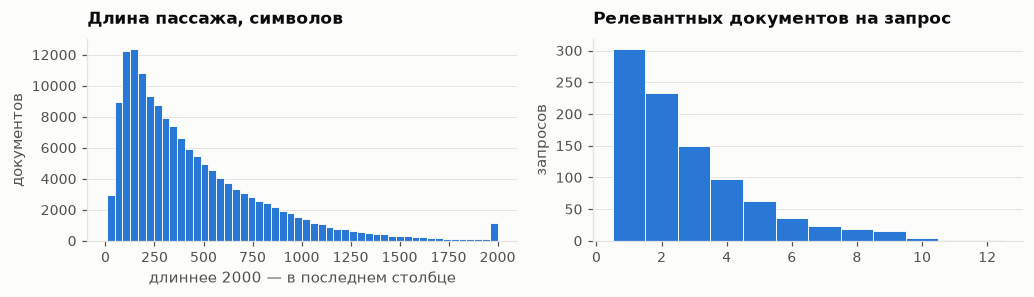

In [7]:
lens = np.array([len(p) for p in PASSAGES])
n_pos = [sum(1 for r in QRELS_DEV[q].values() if r > 0) for q in SP["test_qids"]]
print(f"длина пассажа, символов: медиана {int(np.median(lens))}, "
      f"p90 {int(np.percentile(lens, 90))}, p99 {int(np.percentile(lens, 99))}")
print(f"релевантных на тестовый запрос: медиана {int(np.median(n_pos))}, "
      f"среднее {np.mean(n_pos):.2f}, максимум {max(n_pos)}")

fig, ax = plt.subplots(1, 2, figsize=(9.5, 2.8))
ax[0].hist(np.clip(lens, 0, 2000), bins=50, color=BLUE, edgecolor=SURFACE, linewidth=0.6)
ax[0].set_title("Длина пассажа, символов"); ax[0].set_ylabel("документов")
ax[0].set_xlabel("длиннее 2000 — в последнем столбце")
ax[1].hist(n_pos, bins=np.arange(0.5, 13.5), color=BLUE, edgecolor=SURFACE, linewidth=0.6)
ax[1].set_title("Релевантных документов на запрос"); ax[1].set_ylabel("запросов")
for a in ax:
    a.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

## 2. Метрики

На этих четырёх числах держится весь проект, поэтому они написаны руками и сверены с
эталоном: в NDCG легко ошибиться незаметно — обрезать идеальный порядок не по k, забыть
про релевантные документы, которые вообще не нашлись, — и все сравнения тихо поедут.
Везде `ranked` — документы по убыванию скора, `rel_map` — разметка запроса вида
«документ → оценка».

**Recall@k** — доля релевантных документов запроса в топ-k. **MRR@k** — обратная
позиция первого релевантного. **NDCG@k** — основная метрика качества выдачи:

$$\text{DCG@}k = \sum_{i=1}^{k} \frac{2^{rel_i} - 1}{\log_2(i + 1)}, \qquad
\text{NDCG@}k = \frac{\text{DCG@}k}{\text{IDCG@}k}$$

Вклад документа падает с позицией; деление на IDCG (тот же DCG для идеального порядка)
нормирует результат в [0, 1]. У MIRACL релевантность бинарная, так что NDCG различает
подходы только по позициям.

In [8]:
def dcg_at_k(gains, k):
    """DCG@k. Индексация с нуля, поэтому log2(i+2), а не log2(i+1)."""
    return sum((2.0 ** g - 1.0) / math.log2(i + 2) for i, g in enumerate(gains[:k]))


def ndcg_at_k(ranked, rel_map, k):
    gains = [rel_map.get(d, 0) for d in ranked[:k]]
    idcg = dcg_at_k(sorted(rel_map.values(), reverse=True)[:k], k)   # идеальный порядок
    return dcg_at_k(gains, k) / idcg if idcg > 0 else 0.0


def recall_at_k(ranked, rel_map, k):
    positives = {d for d, r in rel_map.items() if r > 0}
    if not positives:
        return 0.0
    return sum(1 for d in ranked[:k] if d in positives) / len(positives)


def mrr_at_k(ranked, rel_map, k):
    for i, d in enumerate(ranked[:k]):
        if rel_map.get(d, 0) > 0:
            return 1.0 / (i + 1)
    return 0.0

In [9]:
# Сверка с ручным счётом и sklearn — при бинарной релевантности все три обязаны совпасть.
# Плюс края, на которых метрики любят молча ломаться.
from sklearn.metrics import ndcg_score

ranked = ["d1", "d2", "d3", "d4", "d5"]
rel = {"d1": 0, "d2": 1, "d3": 0, "d4": 1, "d5": 0, "d9": 1}    # d9 не нашёлся

manual = ((1 / math.log2(3) + 1 / math.log2(5)) /                        # позиции 2 и 4
          (1 / math.log2(2) + 1 / math.log2(3) + 1 / math.log2(4)))      # идеал
alldocs = ["d1", "d2", "d3", "d4", "d5", "d9"]
sk = ndcg_score(np.array([[rel[d] for d in alldocs]]), np.array([[5, 4, 3, 2, 1, 0]]), k=5)

print(f"NDCG@5:  своя реализация {ndcg_at_k(ranked, rel, 5):.6f} | "
      f"вручную {manual:.6f} | sklearn {sk:.6f}")
print(f"Recall@3 = {recall_at_k(ranked, rel, 3):.4f}  (нашли 1 из 3 релевантных)")
print(f"MRR@5    = {mrr_at_k(ranked, rel, 5):.4f}  (первый релевантный на позиции 2)")

assert abs(ndcg_at_k(ranked, rel, 5) - sk) < 1e-9
assert abs(recall_at_k(ranked, rel, 3) - 1 / 3) < 1e-9
assert abs(mrr_at_k(ranked, rel, 5) - 0.5) < 1e-9

print("\nкрая:")
print("  идеальный порядок      NDCG@5 =", round(ndcg_at_k(["d2", "d4", "d9", "d1", "d3"], rel, 5), 4))
print("  ни одного релевантного NDCG@5 =", round(ndcg_at_k(["d1", "d3", "d5"], rel, 5), 4))
print("  пустая разметка        NDCG@5 =", round(ndcg_at_k(ranked, {}, 5), 4))

NDCG@5:  своя реализация 0.498189 | вручную 0.498189 | sklearn 0.498189
Recall@3 = 0.3333  (нашли 1 из 3 релевантных)
MRR@5    = 0.5000  (первый релевантный на позиции 2)

края:
  идеальный порядок      NDCG@5 = 1.0
  ни одного релевантного NDCG@5 = 0.0
  пустая разметка        NDCG@5 = 0.0


Метрики усредняются по запросам, у которых есть хотя бы один релевантный документ.
Разница между системами часто в третьем знаке, поэтому каждое важное сравнение
проверяется **парным бутстрепом**: пересэмплируем сами запросы с возвратом и смотрим
распределение средней разницы. Парный — обе системы меряются на одних и тех же запросах.

Ниже же — запись результатов: прогон любой системы превращается в строку
`results/metrics.json` и в поквериный NDCG@10 на test (`results/per_query_test.json`),
на котором считаются бутстреп и разбор ошибок.

In [10]:
def evaluate(run, qrels, ks_recall=(10, 100), k=10):
    qids = [q for q in run if any(r > 0 for r in qrels.get(q, {}).values())]
    res = {f"Recall@{kk}": float(np.mean([recall_at_k(run[q], qrels[q], kk) for q in qids]))
           for kk in ks_recall}
    res[f"NDCG@{k}"] = float(np.mean([ndcg_at_k(run[q], qrels[q], k) for q in qids]))
    res[f"MRR@{k}"] = float(np.mean([mrr_at_k(run[q], qrels[q], k) for q in qids]))
    res["n_queries"] = len(qids)
    return res


def per_query_ndcg(run, qrels, k=10):
    return {q: ndcg_at_k(run[q], qrels[q], k) for q in run
            if any(r > 0 for r in qrels.get(q, {}).values())}


def bootstrap_ci(a, b, n_boot=2000, seed=SEED):
    """Парный бутстреп по запросам для разницы b - a: (среднее, нижняя и верхняя граница 95%)."""
    qids = sorted(set(a) & set(b))
    diff = np.array([b[q] - a[q] for q in qids])
    idx = np.random.default_rng(seed).integers(0, len(diff), size=(n_boot, len(diff)))
    boots = diff[idx].mean(axis=1)
    return float(diff.mean()), float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))


def query_type(q):
    """Грубая типология русских вопросов по первому слову."""
    ql = q.lower().strip()
    for pref, name in [("когда", "когда (дата)"), ("сколько", "сколько (число)"),
                       ("где", "где (место)"), ("кто", "кто (человек)"),
                       ("какой", "какой"), ("какая", "какой"), ("какое", "какой"),
                       ("какие", "какой"), ("как называ", "как называется"),
                       ("как ", "как (способ)"), ("что тако", "что такое"), ("что ", "что"),
                       ("почему", "почему"), ("зачем", "зачем"), ("чем ", "чем")]:
        if ql.startswith(pref):
            return name
    return "прочее"


def run_path(tag, split):
    return CACHE / f"run_{tag}_{split}.json"


def save_run(run, tag, split):
    run_path(tag, split).write_text(json.dumps(run, ensure_ascii=False), encoding="utf-8")


def load_run(tag, split):
    return json.loads(run_path(tag, split).read_text(encoding="utf-8"))


def record(tag, label, note=""):
    """Метрики прогона на valid и test -> results/metrics.json,
    поквериный NDCG@10 на test -> results/per_query_test.json."""
    metrics = load_or("metrics", {})
    pq = load_or("per_query_test", {"query_type": {}, "ndcg@10": {}})
    row = {"label": label, "note": note}
    for split in ("valid", "test"):
        keep = set(SP[f"{split}_qids"])
        run = {q: v for q, v in load_run(tag, split).items() if q in keep}
        row[split] = evaluate(run, QRELS_DEV)
        if split == "test":
            pq["ndcg@10"][tag] = per_query_ndcg(run, QRELS_DEV)
    pq["query_type"] = {q: query_type(TOPICS[q]) for q in SP["test_qids"]}
    metrics[tag] = row
    dump(metrics, "metrics")
    dump(pq, "per_query_test")
    print(f"[{label}] test: " + "  ".join(f"{k}={v:.4f}" for k, v in row["test"].items()
                                          if k != "n_queries"))

## 3. Бейзлайны

**BM25** — лексический поиск: слово тем важнее, чем чаще оно в документе и реже в
коллекции. Библиотека `bm25s`, токенизация — стоп-слова плюс стеммер Snowball,
сводящий «кризиса», «кризисом», «кризисы» к одной основе.

**Плотный поиск без дообучения.** `rubert-tiny2` — 29M параметров, обучалась на близость
предложений, а не на поиск. Дообучаем именно её: по исходной задаче модель должна жить
на обычной машине рядом с корпусом, а 29M ещё и обучаются за несколько минут — значит, за
вечер проверяется не одна гипотеза, а полтора десятка. `multilingual-e5-small` — 118M,
обучена под retrieval: то, что разумно поставить с полки, не начиная всё это (префиксы
`query: ` / `passage: ` обязательны).

Пассажи режутся до 256 токенов: это покрывает ~90% корпуса целиком, а матрица внимания
весит `batch × heads × L² × 4` байта — при L=512 один батч просил больше 3 ГБ. Ограничение
одинаково для всех моделей, так что сравнение честное.

In [11]:
MAX_SEQ_LEN, BATCH_SIZE = 256, 128
PREFIXES = {"intfloat/multilingual-e5-small": ("query: ", "passage: "),
            "cointegrated/rubert-tiny2": ("", "")}
BM25_DIR = CACHE / "bm25_index"


def _stemmer():
    import Stemmer
    return Stemmer.Stemmer("russian")


def build_bm25(passages):
    import bm25s
    if BM25_DIR.exists():
        return bm25s.BM25.load(str(BM25_DIR), mmap=False)
    tokens = bm25s.tokenize(list(passages), stopwords="russian", stemmer=_stemmer())
    retriever = bm25s.BM25(method="lucene", k1=0.9, b=0.4)
    retriever.index(tokens)
    retriever.save(str(BM25_DIR))
    return retriever


def bm25_search(retriever, queries, top_k=100):
    import bm25s
    qids = list(queries)
    qtok = bm25s.tokenize([queries[q] for q in qids], stopwords="russian",
                          stemmer=_stemmer(), show_progress=False)
    idx, _ = retriever.retrieve(qtok, k=top_k, n_threads=os.cpu_count() or 4)
    return {q: [DOCIDS[i] for i in idx[r]] for r, q in enumerate(qids)}


def load_st(name_or_path):
    from sentence_transformers import SentenceTransformer
    m = SentenceTransformer(str(name_or_path), device=get_device())
    m.max_seq_length = MAX_SEQ_LEN
    return m


def encode(model, texts, tag, batch_size=BATCH_SIZE, chunk=20_000):
    """Нормированные эмбеддинги с кешем на диск. Кодируем кусками со сбросом кеша MPS:
    одним вызовом на 150 тысячах текстов кеширующий аллокатор MPS набирает несколько
    гигабайт (форма тензора меняется от батча к батчу), и машина уходит в своп."""
    import torch
    key = hashlib.sha256(repr((tag, len(texts), texts[:3], texts[-3:], True,
                               model.max_seq_length)).encode()).hexdigest()[:16]
    path = CACHE / f"emb_{tag}_{key}.npy"
    if path.exists():
        return np.load(path)
    parts = []
    for s in range(0, len(texts), chunk):
        parts.append(model.encode(texts[s:s + chunk], batch_size=batch_size,
                                  normalize_embeddings=True, convert_to_numpy=True))
        if get_device() == "mps":
            torch.mps.empty_cache()
    emb = np.vstack(parts).astype(np.float32)
    np.save(path, emb)
    return emb


def dense_search(q_emb, d_emb, qids, top_k=100, chunk=256):
    """Точный перебор матричным произведением; векторы уже нормированы."""
    import torch
    dev = get_device()
    D = torch.from_numpy(d_emb).to(dev)
    run = {}
    for s in range(0, len(q_emb), chunk):
        top = torch.topk(torch.from_numpy(q_emb[s:s + chunk]).to(dev) @ D.T,
                         k=top_k, dim=1).indices.cpu().numpy()
        for row, order in enumerate(top):
            run[qids[s + row]] = [DOCIDS[i] for i in order]
    return run


def dense_runs(model, tag, splits=("valid", "test"), q_prefix="", d_prefix="", top_k=100):
    """Кодирует корпус и запросы нужных сплитов, сохраняет прогоны."""
    d_emb = encode(model, [d_prefix + p for p in PASSAGES], f"corpus_{tag}")
    for split in splits:
        qids = TRAIN_QIDS if split == "train" else SP[f"{split}_qids"]
        q_emb = encode(model, [q_prefix + TOPICS[q] for q in qids], f"queries_{tag}")
        save_run(dense_search(q_emb, d_emb, qids, top_k=top_k), tag, split)
    return d_emb


EVAL_SETS = {s: {q: TOPICS[q] for q in SP[f"{s}_qids"]} for s in ("valid", "test")}

if RUN_SEARCH:
    retriever = build_bm25(PASSAGES)
    for split, queries in EVAL_SETS.items():
        save_run(bm25_search(retriever, queries), "bm25", split)
    record("bm25", "BM25", "lucene k1=0.9 b=0.4, стеммер Snowball")

    for name, tag, label in [("cointegrated/rubert-tiny2", "rubert_tiny2_zs", "rubert-tiny2, без дообучения"),
                             ("intfloat/multilingual-e5-small", "e5_small_zs", "multilingual-e5-small, без дообучения")]:
        qp, dp = PREFIXES[name]
        dense_runs(load_st(name), tag, q_prefix=qp, d_prefix=dp)
        record(tag, label, f"префиксы {qp!r}/{dp!r}")
        free_memory()

In [12]:
RESULTS = load("metrics")
PQ = load("per_query_test")


def show(tags, cols=("Recall@10", "Recall@100", "NDCG@10", "MRR@10")):
    """Таблица по списку систем из results/metrics.json, в порядке списка, на test."""
    rows = [{"подход": RESULTS[t]["label"], **{c: RESULTS[t]["test"][c] for c in cols}}
            for t in tags]
    return pd.DataFrame(rows).round(4)


def compare(a, b):
    d, lo, hi = bootstrap_ci(PQ["ndcg@10"][a], PQ["ndcg@10"][b])
    return {"A": RESULTS[a]["label"], "B": RESULTS[b]["label"], "ΔNDCG@10 (B − A)": round(d, 4),
            "95% интервал": f"[{lo:+.4f}, {hi:+.4f}]",
            "вывод": "значимо" if (lo > 0 or hi < 0) else "в пределах шума"}


show(["bm25", "rubert_tiny2_zs", "e5_small_zs"])

,подход,Recall@10,Recall@100,NDCG@10,MRR@10
0,BM25,0.6504,0.8558,0.5142,0.5400
1,"rubert-tiny2, без дообучения",0.1796,0.4577,0.1335,0.1615
2,"multilingual-e5-small, без дообучения",0.8835,0.9941,0.7595,0.7905


**Проверка вменяемости пройдена:** e5-small обходит BM25 с большим запасом. Не обошла
бы — значит, забыты префиксы, не нормализованы векторы или перепутаны идентификаторы.

`rubert-tiny2` проигрывает BM25 в разы, тоже ожидаемо: она училась отвечать на «эти два
текста про одно и то же?», а поиск спрашивает «есть ли в тексте ответ?». Этот разрыв и
закрывает дообучение.

Сколько стоит урезание корпуса — сравнение с опубликованными числами на полном корпусе:

In [13]:
# [ОЦЕНКА] опубликованные числа на полном корпусе: MIRACL, Table 2 (arXiv:2210.09984)
# и E5, Table 6 (arXiv:2402.05672)
PUBLISHED = {"bm25": (0.334, 0.661), "e5_small_zs": (0.591, 0.922)}
pd.DataFrame([{
    "модель": RESULTS[t]["label"],
    "NDCG@10 здесь": round(RESULTS[t]["test"]["NDCG@10"], 3), "NDCG@10 на полном корпусе": nd,
    "во сколько раз выше": round(RESULTS[t]["test"]["NDCG@10"] / nd, 2),
    "R@100 здесь": round(RESULTS[t]["test"]["Recall@100"], 3), "R@100 на полном": rc,
} for t, (nd, rc) in PUBLISHED.items()])

,модель,NDCG@10 здесь,NDCG@10 на полном корпусе,во сколько раз выше,R@100 здесь,R@100 на полном
0,BM25,0.514,0.334,1.54,0.856,0.661
1,"multilingual-e5-small, без дообучения",0.759,0.591,1.29,0.994,0.922


Урезание подняло NDCG@10 у обеих моделей — у BM25 в полтора раза, у e5-small в 1.3 раза, —
а их порядок не изменился: задача стала легче, но не перевернулась. Поэтому строки внутри
проекта сравнимы между собой, а с публичным лидербордом — нет. Recall@100 упёрся в потолок (0.994 у e5) и как различитель
бесполезен: дальше основные — NDCG@10, MRR@10 и Recall@10.

## 4. Майнинг сложных негативов

Для контрастивного обучения нужны тройки «запрос — правильный ответ — неправильный».
Случайный документ бесполезен: отличить вопрос про Кеннеди от статьи про пчеловодство
модель умеет и так. Нужны **сложные негативы** — похожие на ответ по словам или теме, но
ответа не содержащие. Берём топ-50 BM25 и топ-50 плотного поиска (e5-small), склеиваем
чередованием, выкидываем размеченное как релевантное, оставляем 8. Майним **только по
train-запросам** — тут утечка возникает незаметнее всего.

Ещё выкидываем кандидатов из статьи правильного ответа: соседний пассаж слишком часто
тоже релевантен, а идентификатор вида `articleId#passageIdx` делает фильтр бесплатным.
Здесь же готовятся негативы из разных «полос» выдачи (позиции 1–5, 6–15, 16–30, 31–50) —
они понадобятся в разделе 5.

In [14]:
N_NEG, MINE_DEPTH = 8, 50
BANDS = {"band_1_5": (1, 5), "band_6_15": (6, 15), "band_16_30": (16, 30), "band_31_50": (31, 50)}


def article_of(docid):
    return docid.split("#", 1)[0]


def mining_runs():
    """Кандидаты для майнинга: топ-50 BM25 и e5-small по train-запросам."""
    queries = {q: TOPICS[q] for q in TRAIN_QIDS}
    save_run(bm25_search(build_bm25(PASSAGES), queries, top_k=MINE_DEPTH), "bm25", "train")
    qp, dp = PREFIXES["intfloat/multilingual-e5-small"]
    dense_runs(load_st("intfloat/multilingual-e5-small"), "e5_small_zs", splits=("train",),
               q_prefix=qp, d_prefix=dp, top_k=MINE_DEPTH)
    free_memory()


def mine_negatives(out_path=MINI / "train_pairs.jsonl"):
    runs = {"BM25": load_run("bm25", "train"), "плотный поиск (e5-small)": load_run("e5_small_zs", "train")}

    # что вообще лежит в топ-50: сколько проверено человеком, а сколько не смотрел никто
    composition = {}
    for src, run in runs.items():
        c = Counter()
        for q in TRAIN_QIDS:
            rel = QRELS_TRAIN.get(q, {})
            gold_articles = {article_of(d) for d, r in rel.items() if r > 0}
            for d in run[q][:MINE_DEPTH]:
                if d in rel:
                    c["человек: РЕЛЕВАНТЕН" if rel[d] > 0 else "человек: нерелевантен"] += 1
                elif article_of(d) in gold_articles:
                    c["не размечен, но из статьи правильного ответа"] += 1
                else:
                    c["не размечен"] += 1
        composition[src] = {k: v / sum(c.values()) for k, v in c.items()}

    bm25_run, dense = runs["BM25"], runs["плотный поиск (e5-small)"]
    rows, filtered = [], Counter()
    for q in TRAIN_QIDS:
        rel = QRELS_TRAIN.get(q, {})
        positives = [d for d, r in rel.items() if r > 0]
        gold_articles = {article_of(d) for d in positives}
        cands, seen = [], set()
        for a, b in zip(bm25_run[q][:MINE_DEPTH], dense[q][:MINE_DEPTH]):   # чередуем источники
            for d in (a, b):
                if d in seen:
                    continue
                seen.add(d)
                if rel.get(d, 0) > 0:
                    filtered["позитив по разметке"] += 1
                elif article_of(d) in gold_articles:
                    filtered["та же статья, что у позитива"] += 1
                else:
                    cands.append(d)
        negs = cands[:N_NEG]
        filtered["оставлено негативов"] += len(negs)

        # негативы из полос плотной выдачи — для кривой «трудность против качества»
        bands = {}
        for bname, (lo, hi) in BANDS.items():
            picked = [d for d in dense[q][lo - 1:hi]
                      if rel.get(d, 0) == 0 and article_of(d) not in gold_articles][:2]
            bands[bname] = picked
        for pos in positives:
            rows.append({"qid": q, "query": TOPICS[q], "pos": pos, "negs": negs,
                         # подтверждённые человеком негативы — отдельным полем
                         "judged_negs": [d for d, r in rel.items() if r == 0][:N_NEG], **bands})

    with open(out_path, "w", encoding="utf-8") as f:
        for r in rows:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")

    band_rows = {b: sum(len(r[b]) >= 2 for r in rows) for b in BANDS}
    dump({"composition": composition, "filtered": dict(filtered), "n_rows": len(rows),
          "n_queries": len(TRAIN_QIDS), "rows_with_band_negs": band_rows,
          "rows_with_bands_6_50": sum(all(len(r[b]) >= 2 for b in ("band_6_15", "band_16_30", "band_31_50"))
                                      for r in rows)},
         "mining")
    dump(negatives_hardness(rows, bm25_run, dense), "negatives")


def negatives_hardness(rows, bm25_run, dense, n=2):
    """Где в выдаче стоят намайненные и человеческие негативы — на тех строках,
    где хватило обоих видов (ровно на них идёт сравнение в разделе 5)."""
    fair = [r for r in rows if len(r["negs"]) >= n and len(r["judged_negs"]) >= n]
    out = {}
    for kind, field in (("намайненные (BM25 + e5)", "negs"), ("человеческие, rel=0", "judged_negs")):
        pos_d, outside, total = [], 0, 0
        for r in fair:
            for d in r[field][:n]:
                total += 1
                in_b, in_d = d in bm25_run.get(r["qid"], []), d in dense.get(r["qid"], [])
                if not in_b and not in_d:
                    outside += 1
                if in_d:
                    pos_d.append(dense[r["qid"]].index(d) + 1)
        pos_d = np.array(pos_d)
        out[kind] = {"медиана позиции в выдаче": int(np.median(pos_d)),
                     "доля в топ-10": float(np.mean(pos_d <= 10)),
                     "вне топ-50": outside / total}
    return out


if RUN_SEARCH:
    mining_runs()
    mine_negatives()

In [15]:
mining = load("mining")
print(f"train-запросов: {mining['n_queries']:,}, обучающих строк «запрос — позитив»: "
      f"{mining['n_rows']:,}\n")
print("что лежит в топ-50 кандидатов:")
display(pd.DataFrame(mining["composition"]).T.map(lambda v: f"{v:.1%}")
        [["не размечен", "не размечен, но из статьи правильного ответа",
          "человек: нерелевантен", "человек: РЕЛЕВАНТЕН"]])
print("фильтрация:", ", ".join(f"{k} — {v:,}" for k, v in mining["filtered"].items()))

train-запросов: 4,683, обучающих строк «запрос — позитив»: 10,000

что лежит в топ-50 кандидатов:


,не размечен,"не размечен, но из статьи правильного ответа",человек: нерелевантен,человек: РЕЛЕВАНТЕН
BM25,84.4%,4.5%,7.4%,3.7%
плотный поиск (e5-small),80.2%,6.7%,8.9%,4.2%


фильтрация: позитив по разметке — 9,943, оставлено негативов — 37,464, та же статья, что у позитива — 25,182


**~4% кандидатов — подтверждённые человеком позитивы**, их выкидываем по разметке. И
**~80% никем не размечены**: асессоры смотрели только выдачу систем, значит, среди них
есть непроверенные релевантные — **ложные негативы**, главная головная боль майнинга.

In [16]:
TRAIN_ROWS = [json.loads(l) for l in open(MINI / "train_pairs.jsonl", encoding="utf-8")]
r = next(x for x in TRAIN_ROWS if "убийцу Джона Кеннеди" in x["query"])
print(f"ЗАПРОС: {r['query']}")
print(f"\nПОЗИТИВ по разметке:\n  {BY_ID[r['pos']][:340]}")
for d in r["negs"][:2]:
    print(f"\nНАМАЙНЕНО КАК НЕГАТИВ [{d}]:\n  {BY_ID[d][:340]}")

ЗАПРОС: Как звали предполагаемого убийцу Джона Кеннеди?

ПОЗИТИВ по разметке:
  Убийство Джона Кеннеди. В 1966 году окружной прокурор Нового Орлеана Джим Гаррисон начал собственное расследование убийства. Основными подозреваемыми он считал бывшего пилота авиакомпании Eastern Air Lines и новоорлеанского банкира . По его версии, убийство было организовано военизированной группой ультраправых активистов, имевшей связи с

НАМАЙНЕНО КАК НЕГАТИВ [39314#0]:
  Освальд, Ли Харви. Ли Ха́рви О́свальд (; 18 октября 1939, Новый Орлеан, Луизиана, США — 24 ноября 1963, Даллас, Техас, США) — единственный официальный подозреваемый в убийстве американского президента Джона Кеннеди. По закону США умерший не может быть судим, но по выводам Комиссии Уоррена он назван убийцей.

НАМАЙНЕНО КАК НЕГАТИВ [2087315#9]:
  Убийство Мартина Лютера Кинга. Он был первым, кто публично проинформировал людей о смерти Мартина Лютера Кинга, чем вызвал крики и вопли в толпе.
Некоторые из помощников Роберта Кеннеди не исключа

Первый «негатив» — ложный: запрос про предполагаемого убийцу Кеннеди, а в негативы
попала статья про **Ли Харви Освальда**. Пары просто нет в qrels, фильтр «та же статья»
не помог — статьи разные. Поймать такое может только смысловая проверка, то есть судья
из раздела 8.

## 5. Дообучение двубашенного эмбеддера

В **двубашенной** (bi-encoder) модели запрос и документ кодируются независимо,
релевантность — скалярное произведение векторов. Корпус за счёт этого кодируется
заранее; плата — запрос и документ не видят друг друга внутри модели.

Лосс — `MultipleNegativesRankingLoss`, он же InfoNCE с негативами из батча:

$$\mathcal{L} = -\log \frac{\exp(s(q, p^+) / \tau)}{\sum_{p \in B} \exp(s(q, p) / \tau)}$$

Здесь $s(q, p)$ — косинус между векторами запроса и документа, $p^+$ — правильный документ,
$B$ — все документы батча, $\tau = 0.05$ — температура: косинусы лежат в узком диапазоне,
и деление на $\tau$ растягивает мелкие различия. В знаменателе позитивы всех остальных
запросов батча — для нашего запроса они и есть негативы. Отсюда прямая зависимость от
размера батча. Явные сложные негативы, если они есть, просто добавляются в знаменатель.

**Подводный камень:** у запроса бывает несколько релевантных пассажей, и если две такие
строки попадут в один батч, лосс посчитает позитив соседней негативом. Лечится
сэмплером `NO_DUPLICATES`.

Все варианты ниже — одна и та же `rubert-tiny2`, 2 эпохи по 10 тысячам пар «запрос —
позитив»; отличаются батч, learning rate и источник негативов. Каждая строка —
отдельная гипотеза.

In [17]:
BASE = "cointegrated/rubert-tiny2"

#  имя                   поле негативов  негативов  батч  lr      только строки, где есть   подпись
CONFIGS = [
    ("ft_inbatch_bs64",    None,          0,  64, 4e-5,   (), "дообучен, негативы только из батча (батч 64)"),
    ("ft_mined_bs64",      "negs",        2,  64, 4e-5,   (), "дообучен + сложные негативы (батч 64)"),
    # размер батча при фиксированном lr — и с lr, масштабированным вместе с батчем
    ("ft_inbatch_bs16",    None,          0,  16, 4e-5,   (), "дообучен, батч 16, lr 4e-5"),
    ("ft_inbatch_bs128",   None,          0, 128, 4e-5,   (), "дообучен, батч 128, lr 4e-5"),
    ("ft_inbatch_bs16_lr", None,          0,  16, 1e-5,   (), "дообучен, батч 16, lr 1e-5"),
    ("ft_inbatch_bs96",    None,          0,  96, 6e-5,   (), "дообучен, батч 96, lr 6e-5"),
    ("ft_inbatch_bs128_lr", None,         0, 128, 8e-5,   (), "дообучен, батч 128, lr 8e-5"),
    ("ft_inbatch_bs256_lr", None,         0, 256, 1.6e-4, (), "дообучен, батч 256, lr 1.6e-4"),
    # подобранные автоматически негативы против человеческих — на одних и тех же строках
    ("ft_mined_fair",  "negs",        2, 64, 4e-5, ("negs", "judged_negs"), "дообучен, негативы подобраны автоматически"),
    ("ft_judged_fair", "judged_negs", 2, 64, 4e-5, ("negs", "judged_negs"), "дообучен, негативы человеческие (rel=0)"),
    # трудность негатива: полосы плотной выдачи, тоже на общих строках
    ("ft_band_6_15",  "band_6_15",  2, 64, 4e-5, ("band_6_15", "band_16_30", "band_31_50"), "дообучен, негативы с позиций 6–15 (труднее)"),
    ("ft_band_16_30", "band_16_30", 2, 64, 4e-5, ("band_6_15", "band_16_30", "band_31_50"), "дообучен, негативы с позиций 16–30"),
    ("ft_band_31_50", "band_31_50", 2, 64, 4e-5, ("band_6_15", "band_16_30", "band_31_50"), "дообучен, негативы с позиций 31–50 (легче)"),
]


def make_mps_cleaner(every=10):
    """Кеширующий аллокатор MPS держит блоки под каждую встреченную форму тензора, а
    sentence-transformers паддит батч по самой длинной строке — форма меняется почти каждый
    шаг. Без периодического сброса кеш дорастал до 13 ГБ, и шаг замедлялся с 0.4 до 14 секунд."""
    import torch
    from transformers import TrainerCallback

    class MPSCacheCleaner(TrainerCallback):
        def on_step_end(self, args, state, control, **kwargs):
            if state.global_step % every == 0 and torch.backends.mps.is_available():
                torch.mps.empty_cache()
            return control

    return MPSCacheCleaner()


def build_dataset(rows, neg_field, n_negs, require_fields=()):
    """neg_field=None — пары (запрос, позитив), негативы только из батча.
    require_fields — у каких полей должно хватать негативов, чтобы строка попала в обучение:
    когда сравниваются два источника негативов, оба прогона должны идти на одних строках."""
    from datasets import Dataset
    data = {"anchor": [], "positive": [], **{f"negative_{i}": [] for i in range(n_negs)}}
    for r in rows:
        if any(len(r.get(f) or []) < n_negs for f in require_fields):
            continue
        if neg_field is not None and len(r[neg_field]) < n_negs:
            continue
        data["anchor"].append(r["query"])
        data["positive"].append(BY_ID[r["pos"]])
        for i in range(n_negs):
            data[f"negative_{i}"].append(BY_ID[r[neg_field][i]])
    return Dataset.from_dict(data)


def train_biencoder(name, neg_field, n_negs, batch_size, lr, require_fields=(), epochs=2):
    import torch
    from sentence_transformers import SentenceTransformerTrainer, SentenceTransformerTrainingArguments
    from sentence_transformers.losses import MultipleNegativesRankingLoss
    from sentence_transformers.training_args import BatchSamplers

    torch.manual_seed(SEED); random.seed(SEED)
    rows = [json.loads(l) for l in open(MINI / "train_pairs.jsonl", encoding="utf-8")]
    ds = build_dataset(rows, neg_field, n_negs, require_fields)
    model = load_st(BASE)
    args = SentenceTransformerTrainingArguments(
        output_dir=str(MODELS / name), num_train_epochs=epochs, per_device_train_batch_size=batch_size,
        learning_rate=lr, warmup_ratio=0.1, logging_steps=10, save_strategy="no", eval_strategy="no",
        batch_sampler=BatchSamplers.NO_DUPLICATES, seed=SEED, fp16=False, bf16=False,
        dataloader_num_workers=0, report_to=[])
    trainer = SentenceTransformerTrainer(model=model, args=args, train_dataset=ds,
                                         loss=MultipleNegativesRankingLoss(model),   # scale=20 -> τ=0.05
                                         callbacks=[make_mps_cleaner()])
    t0 = time.time()
    trainer.train()
    model.save(str(MODELS / name / "final"))

    logs = load_or("train_logs", {})
    logs[name] = {"batch_size": batch_size, "lr": lr, "epochs": epochs, "n_rows": len(ds),
                  "negatives": neg_field or "только из батча", "train_seconds": round(time.time() - t0, 1),
                  "loss": [[h["epoch"], h["loss"]] for h in trainer.state.log_history if "loss" in h]}
    dump(logs, "train_logs")
    return model


if RUN_TRAIN:
    for name, field, n_negs, bs, lr, req, label in CONFIGS:
        model = train_biencoder(name, field, n_negs, bs, lr, req)
        dense_runs(model, name)
        record(name, label, f"батч {bs}, lr {lr:g}, негативы: {field or 'только из батча'}")
        del model
        free_memory()

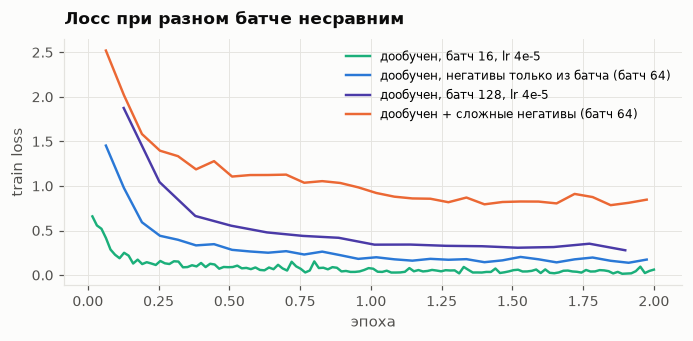

время обучения, мин: дообучен, негативы только из батча (батч 64) — 2.4, дообучен + сложные негативы (батч 64) — 9.3


In [18]:
TRAIN_LOGS = load("train_logs")
fig, ax = plt.subplots(figsize=(6.4, 3.2))
for name, color in [("ft_inbatch_bs16", AQUA), ("ft_inbatch_bs64", BLUE),
                    ("ft_inbatch_bs128", "#4a3aa7"), ("ft_mined_bs64", ORANGE)]:
    if TRAIN_LOGS[name]["loss"]:               # лосс пишется раз в 10 шагов
        ep, loss = zip(*TRAIN_LOGS[name]["loss"])
        ax.plot(ep, loss, color=color, lw=1.6, label=RESULTS[name]["label"])
ax.set_xlabel("эпоха"); ax.set_ylabel("train loss")
ax.set_title("Лосс при разном батче несравним")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print("время обучения, мин: " + ", ".join(f"{RESULTS[n]['label']} — {TRAIN_LOGS[n]['train_seconds'] / 60:.1f}"
                                          for n in ("ft_inbatch_bs64", "ft_mined_bs64")))

Лоссы при разном батче несравнимы: больше негативов в знаменателе — задача формально
труднее, лосс при том же качестве выше. Сравнивать надо по метрикам.

In [19]:
show(["rubert_tiny2_zs", "bm25", "ft_inbatch_bs64", "ft_mined_bs64", "e5_small_zs"])

,подход,Recall@10,Recall@100,NDCG@10,MRR@10
0,"rubert-tiny2, без дообучения",0.1796,0.4577,0.1335,0.1615
1,BM25,0.6504,0.8558,0.5142,0.5400
2,"дообучен, негативы только из батча (батч 64)",0.6699,0.8887,0.5369,0.5903
3,дообучен + сложные негативы (батч 64),0.6869,0.8898,0.5533,0.6063
4,"multilingual-e5-small, без дообучения",0.8835,0.9941,0.7595,0.7905


Разница в третьем знаке на 947 запросах может быть шумом, поэтому каждое сравнение
проверяется парным бутстрепом:

In [20]:
pd.DataFrame([compare(a, b) for a, b in [
    ("rubert_tiny2_zs", "ft_inbatch_bs64"),
    ("bm25", "ft_inbatch_bs64"),
    ("ft_inbatch_bs64", "ft_mined_bs64"),
    ("bm25", "ft_mined_bs64"),
    ("ft_mined_bs64", "e5_small_zs"),
]])

,A,B,ΔNDCG@10 (B − A),95% интервал,вывод
0,"rubert-tiny2, без дообучения","дообучен, негативы только из батча (батч 64)",0.4035,"[+0.3822, +0.4251]",значимо
1,BM25,"дообучен, негативы только из батча (батч 64)",0.0227,"[-0.0026, +0.0477]",в пределах шума
2,"дообучен, негативы только из батча (батч 64)",дообучен + сложные негативы (батч 64),0.0163,"[+0.0078, +0.0246]",значимо
3,BM25,дообучен + сложные негативы (батч 64),0.0390,"[+0.0122, +0.0641]",значимо
4,дообучен + сложные негативы (батч 64),"multilingual-e5-small, без дообучения",0.2062,"[+0.1864, +0.2263]",значимо


Дообучение на десяти тысячах пар поднимает `rubert-tiny2` вчетверо. Но **одни негативы
из батча при батче 64 дают уровень BM25, а не выше**: +0.023 к BM25 в пределах шума.
Уверенно обходят BM25 варианты со сложными негативами — и, как выяснится ниже, с большим
батчем. До готовой `e5-small` всё равно далеко.

### Размер батча: как сломался эксперимент

Размер батча в MNRL — буквально количество негативов, так что ожидание «больше батч →
лучше». При фиксированном lr 4e-5 вышло обратное:

In [21]:
show(["ft_inbatch_bs16", "ft_inbatch_bs64", "ft_inbatch_bs128"], cols=("NDCG@10", "MRR@10"))

,подход,NDCG@10,MRR@10
0,"дообучен, батч 16, lr 4e-5",0.5391,0.5903
1,"дообучен, негативы только из батча (батч 64)",0.5369,0.5903
2,"дообучен, батч 128, lr 4e-5",0.5324,0.5845


Результат против всей литературы, так что подозрение падает на постановку. И
справедливо: при фиксированном числе эпох больший батч получает пропорционально
**меньше шагов оптимизатора** (10 000 строк: батч 16 → 1250 шагов, батч 128 → 157).
Разводим факторы, масштабируя learning rate линейно вместе с батчем
([linear scaling rule](https://arxiv.org/abs/1706.02677)):

In [22]:
show(["ft_inbatch_bs16_lr", "ft_inbatch_bs64", "ft_inbatch_bs96", "ft_inbatch_bs128_lr",
      "ft_inbatch_bs256_lr"], cols=("Recall@10", "NDCG@10", "MRR@10"))

,подход,Recall@10,NDCG@10,MRR@10
0,"дообучен, батч 16, lr 1e-5",0.6357,0.5096,0.5646
1,"дообучен, негативы только из батча (батч 64)",0.6699,0.5369,0.5903
2,"дообучен, батч 96, lr 6e-5",0.6753,0.5433,0.5940
3,"дообучен, батч 128, lr 8e-5",0.6869,0.5504,0.5988
4,"дообучен, батч 256, lr 1.6e-4",0.7039,0.5592,0.6031


Теперь монотонно. Причём батч 256 вообще без явных негативов обошёл вариант со сложными
негативами на батче 64: число негативов внутри батча оказалось сильным рычагом. Совместить
большой батч со сложными негативами не вышло: батч 128 с двумя негативами — это
512 последовательностей одновременно, и обучение упало по памяти MPS; прогон на батче 96
тоже оборвался, не дойдя до конца.

### Человеческие негативы против подобранных автоматически

В qrels есть **человеческие негативы** — пары, которые асессор посмотрел и признал
нерелевантными. Они тоже сложные, но ошибок среди них нет: каждую проверил человек.
Гипотеза: они должны обучать лучше, чем документы, подобранные автоматически, — среди тех
есть ложные негативы. Оба прогона идут на одном и том же множестве строк.

In [23]:
display(show(["ft_mined_fair", "ft_judged_fair"], cols=("Recall@10", "NDCG@10", "MRR@10")))
pd.DataFrame([compare("ft_mined_fair", "ft_judged_fair")])

,подход,Recall@10,NDCG@10,MRR@10
0,"дообучен, негативы подобраны автоматически",0.6745,0.5402,0.5905
1,"дообучен, негативы человеческие (rel=0)",0.6185,0.5014,0.5598


,A,B,ΔNDCG@10 (B − A),95% интервал,вывод
0,"дообучен, негативы подобраны автоматически","дообучен, негативы человеческие (rel=0)",-0.0388,"[-0.0507, -0.0271]",значимо


**Гипотеза опровергнута, и с запасом.** Первое объяснение — что человеческие негативы
просто легче: их собирали в 2022 году выдачей тогдашних систем, а наши подобраны более
сильной e5-small. Проверяем, на каких позициях **нашей** плотной выдачи стоят те и другие:

In [24]:
hard = load("negatives")
pd.DataFrame([{"вид негатива": k, **{kk: (f"{vv:.1%}" if isinstance(vv, float) else vv)
                                      for kk, vv in v.items()},
               "NDCG@10 после обучения": RESULTS[t]["test"]["NDCG@10"]}
              for (k, v), t in zip(hard.items(), ["ft_mined_fair", "ft_judged_fair"])]).round(4)

,вид негатива,медиана позиции в выдаче,доля в топ-10,вне топ-50,NDCG@10 после обучения
0,намайненные (BM25 + e5),9,58.1%,0.0%,0.5402
1,"человеческие, rel=0",7,73.1%,3.1%,0.5014


Не подтвердилось: человеческие негативы **труднее** по всем показателям. Вывод обратный —
**более трудные негативы обучили хуже.** Сам эффект известен, но его обычно не отделить
от другого объяснения: среди слишком трудных негативов прячутся неразмеченные
релевантные (это и чинит [NV-Retriever](https://arxiv.org/html/2407.15831v1)). Здесь
негативы проверены асессором, так что остаётся сама трудность.

Превращаем точку в кривую: обучаем ту же модель на негативах из разных полос выдачи.
Полосу 1–5 не берём — там негативов хватает только у 40% строк, верхушка занята самими
ответами и соседними пассажами тех же статей.

,подход,Recall@10,NDCG@10,MRR@10
0,"дообучен, негативы с позиций 6–15 (труднее)",0.6877,0.5514,0.6012
1,"дообучен, негативы с позиций 16–30",0.6991,0.5603,0.6094
2,"дообучен, негативы с позиций 31–50 (легче)",0.6885,0.5504,0.5992


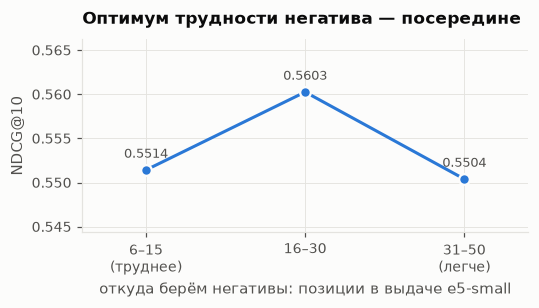

,A,B,ΔNDCG@10 (B − A),95% интервал,вывод
0,"дообучен, негативы с позиций 6–15 (труднее)","дообучен, негативы с позиций 16–30",0.0088,"[+0.0028, +0.0149]",значимо
1,"дообучен, негативы с позиций 31–50 (легче)","дообучен, негативы с позиций 16–30",0.0099,"[+0.0050, +0.0153]",значимо


In [25]:
BANDS_T = ["ft_band_6_15", "ft_band_16_30", "ft_band_31_50"]
display(show(BANDS_T, cols=("Recall@10", "NDCG@10", "MRR@10")))

vals = [RESULTS[b]["test"]["NDCG@10"] for b in BANDS_T]
fig, ax = plt.subplots(figsize=(5, 2.9))
ax.plot(range(3), vals, marker="o", color=BLUE, markeredgecolor=SURFACE, markeredgewidth=1.5)
for i, v in enumerate(vals):
    ax.annotate(f"{v:.4f}", (i, v), xytext=(0, 8), textcoords="offset points",
                ha="center", fontsize=8.5, color=INK_2)
ax.set_xticks(range(3), ["6–15\n(труднее)", "16–30", "31–50\n(легче)"])
ax.set_xlim(-0.4, 2.4); ax.set_ylim(min(vals) - 0.006, max(vals) + 0.006)
ax.set_xlabel("откуда берём негативы: позиции в выдаче e5-small")
ax.set_ylabel("NDCG@10")
ax.set_title("Оптимум трудности негатива — посередине")
plt.tight_layout(); save(fig, "negative-hardness"); plt.show()
pd.DataFrame([compare("ft_band_6_15", "ft_band_16_30"), compare("ft_band_31_50", "ft_band_16_30")])

Перевёрнутая парабола, оптимум посередине: слишком трудные негативы вредят, слишком
лёгкие ничему не учат. Разница в третьем знаке, но обе стороны значимы по парному
бутстрепу. Это же объясняет провал предыдущей гипотезы — человеческие негативы сидели на
медианной позиции 7, в зоне «слишком трудно».

## 6. Кросс-энкодер-реранкер

У двубашенной модели есть потолок, и он архитектурный: всё взаимодействие запроса с
документом сжато в одно скалярное произведение. Поэтому поиск строят **воронкой** —
быстрый этап отбирает кандидатов, точный и дорогой переставляет верхушку.

**Кросс-энкодер** получает пару целиком — `[CLS] запрос [SEP] документ [SEP]` — и выдаёт
одно число. Внимание работает между токенами запроса и документа, поэтому он видит то,
чего двубашенная модель увидеть не может: например, что в документе стоит именно та
дата, о которой спрашивают. Скор зато нельзя посчитать заранее, так что пускают его на
топ-50 быстрого поиска, и меняет он только порядок внутри.

План был сравнить три семейства лоссов ранжирования (pointwise BCE, pairwise RankNet,
listwise LambdaLoss). Дальше первого, pointwise, дело не пошло: он не обучился, и
пришлось разбираться почему.

In [26]:
def pointwise_dataset(rows, n_negs=4):
    """Пары (запрос, документ, метка): позитив и n_negs подобранных негативов на строку."""
    from datasets import Dataset
    q, d, y = [], [], []
    for r in rows:
        for doc, label in [(r["pos"], 1.0)] + [(n, 0.0) for n in r["negs"][:n_negs]]:
            q.append(r["query"]); d.append(BY_ID[doc]); y.append(label)
    return Dataset.from_dict({"query": q, "passage": d, "label": y})


def train_cross_encoder(ds, base=BASE, epochs=1, lr=4e-5, batch_size=160, out=None):
    import torch
    from sentence_transformers.cross_encoder import (CrossEncoder, CrossEncoderTrainer,
                                                     CrossEncoderTrainingArguments, losses)
    torch.manual_seed(SEED); random.seed(SEED)
    model = CrossEncoder(base, num_labels=1, device=get_device(), max_length=MAX_SEQ_LEN)
    args = CrossEncoderTrainingArguments(
        output_dir=str(out or MODELS / "ce_tmp"), num_train_epochs=epochs,
        per_device_train_batch_size=batch_size, learning_rate=lr, warmup_ratio=0.1,
        logging_steps=20, save_strategy="no", eval_strategy="no", seed=SEED, fp16=False,
        bf16=False, dataloader_num_workers=0, report_to=[])
    trainer = CrossEncoderTrainer(model=model, args=args, train_dataset=ds,
                                  loss=losses.BinaryCrossEntropyLoss(model))
    trainer.train()
    return model, [h["loss"] for h in trainer.state.log_history if "loss" in h]


def rerank(model, base_tag, split, top_n=50):
    """Переставляет топ-N базовой выдачи; хвост остаётся как был. Возвращает (прогон, мс/запрос)."""
    out, t0 = {}, time.time()
    for q, ranked in load_run(base_tag, split).items():
        head = ranked[:top_n]
        scores = model.predict([[TOPICS[q], BY_ID[d]] for d in head], batch_size=128,
                               show_progress_bar=False)
        out[q] = [head[i] for i in np.argsort(-np.asarray(scores))] + ranked[top_n:]
    return out, 1000 * (time.time() - t0) / len(out)


def probe_cross_encoders(rows):
    """Почему не учится: тот же код на rubert-tiny2 с разным числом эпох и на 12-слойной e5-small.
    AUC считается на своих обучающих парах и на отложенных."""
    from sklearn.metrics import roc_auc_score
    train_ds, val_ds = pointwise_dataset(rows[:4000]), pointwise_dataset(rows[4000:4800])
    val_pairs = list(zip(val_ds["query"], val_ds["passage"]))
    tr_pairs = list(zip(train_ds["query"][:2000], train_ds["passage"][:2000]))
    out = []
    for base, epochs, lr in [(BASE, 1, 1e-4), (BASE, 4, 1e-4), (BASE, 8, 2e-4),
                             ("intfloat/multilingual-e5-small", 1, 4e-5),
                             ("intfloat/multilingual-e5-small", 2, 4e-5)]:
        m, losses_ = train_cross_encoder(train_ds, base=base, epochs=epochs, lr=lr, batch_size=32)
        out.append({"модель": base.split("/")[-1], "эпох": epochs, "lr": lr,
                    "AUC на своих парах": roc_auc_score(train_ds["label"][:2000], m.predict(tr_pairs)),
                    "AUC на отложенных": roc_auc_score(val_ds["label"], m.predict(val_pairs))})
        del m
        free_memory()
    return out


if RUN_RERANKER:
    rows = [json.loads(l) for l in open(MINI / "train_pairs.jsonl", encoding="utf-8")]
    ds = pointwise_dataset(rows)
    ce, losses_ = train_cross_encoder(ds, out=MODELS / "ce_bce")
    rr = {"base": "ft_mined_bs64", "top_n": 50, "n_pairs": len(ds),
          "positive_share": float(np.mean(ds["label"])), "loss_first": losses_[0], "loss_last": losses_[-1]}
    for split in ("valid", "test"):
        keep = set(SP[f"{split}_qids"])
        run, ms = rerank(ce, "ft_mined_bs64", split)
        rr[split] = {"база": evaluate({q: v for q, v in load_run("ft_mined_bs64", split).items() if q in keep}, QRELS_DEV),
                     "после реранкера": evaluate({q: v for q, v in run.items() if q in keep}, QRELS_DEV),
                     "мс на запрос": ms}
    del ce
    free_memory()
    rr["probe"] = probe_cross_encoders(rows)
    dump(rr, "reranker")

In [27]:
rr = load("reranker")
p = rr["positive_share"]
prior_entropy = -(p * math.log(p) + (1 - p) * math.log(1 - p))
print(f"обучающих пар {rr['n_pairs']:,}, доля позитивов {p:.2f}")
print(f"лосс: в начале {rr['loss_first']:.4f}, в конце {rr['loss_last']:.4f}; "
      f"энтропия априорного распределения {prior_entropy:.4f}\n")
display(pd.DataFrame({k: {m: v[k] for m, v in rr["test"].items() if isinstance(v, dict)}
                      for k in ("NDCG@10", "MRR@10", "Recall@10")}).round(4))
print(f"реранкер: {rr['test']['мс на запрос']:.0f} мс на запрос (топ-{rr['top_n']})\n")
print("почему не учится — тот же код на разных моделях:")
pd.DataFrame(rr["probe"]).assign(lr=lambda d: d["lr"].map("{:g}".format)).round(4)

обучающих пар 50,000, доля позитивов 0.20
лосс: в начале 0.6396, в конце 0.5019; энтропия априорного распределения 0.5004



,NDCG@10,MRR@10,Recall@10
база,0.5533,0.6063,0.6869
после реранкера,0.1411,0.1544,0.2356


реранкер: 97 мс на запрос (топ-50)

почему не учится — тот же код на разных моделях:


,модель,эпох,lr,AUC на своих парах,AUC на отложенных
0,rubert-tiny2,1,0.0001,0.8295,0.6129
1,rubert-tiny2,4,0.0001,0.9990,0.6100
2,rubert-tiny2,8,0.0002,1.0000,0.5904
3,multilingual-e5-small,1,4e-05,0.5730,0.5969
4,multilingual-e5-small,2,4e-05,0.8900,0.8154


Реранкер **не обучился**, и это видно по трём числам. Финальный лосс почти совпал с
энтропией априорного распределения: при доле позитивов 0.2 модель, которая всем парам
отвечает «0.2», получает ровно такой лосс. То есть она не выучила ничего сверх базовой
частоты — и после переранжирования NDCG@10 упал с 0.553 до 0.141.

Проверка на разных моделях разводит две версии — «мало данных» и «мало ёмкости».
`rubert-tiny2` (3 слоя) запоминает свои пары вплоть до AUC 1.0, а на отложенных застревает
около 0.6 сколько эпох ни давай: запоминание без обобщения. 12-слойная `e5-small` на тех же
данных за две эпохи выходит на **0.82** на отложенных. Значит, дело в ёмкости: трёхслойной
модели мало для попарного чтения запроса с документом. Реранкер на e5-small поверх выдачи
до конца не доводился — это первый пункт в «что дальше».

## 7. ANN-индекс

Точный перебор по 150 тысячам векторов на ноутбуке возможен, по 150 миллионам — нет.
Берём **HNSW**: многослойный граф, где нижний слой содержит все точки, а каждый
следующий — прореженное подмножество предыдущего. Верхние слои дают длинные прыжки,
нижние — точную доводку. Главная ручка — **`efSearch`**, размер очереди кандидатов.

Ниже два разных recall: **относительно точного перебора** — качество самого индекса;
поисковый NDCG@10 — против человеческой разметки. Индекс может терять несколько процентов
соседей, а конечная метрика не двинется: теряются нерелевантные с хвоста.

In [28]:
def run_ann(tag="ft_mined_bs64", top_k=100, ef_grid=(160, 320, 640)):
    import hnswlib
    import torch
    model = load_st(MODELS / tag / "final")
    d_emb = encode(model, PASSAGES, f"corpus_{tag}")
    qids = SP["test_qids"]
    q_emb = model.encode([TOPICS[q] for q in qids], normalize_embeddings=True,
                         convert_to_numpy=True).astype(np.float32)

    # эталон — точный перебор; время и батчем на ускорителе, и по одному запросу на CPU
    dev = get_device()
    D, Q = torch.from_numpy(d_emb).to(dev), torch.from_numpy(q_emb).to(dev)
    t0 = time.time()
    exact = torch.topk(Q @ D.T, k=top_k, dim=1).indices.cpu().numpy()
    exact_batched_ms = 1000 * (time.time() - t0) / len(qids)
    Dc, t0 = torch.from_numpy(d_emb), time.time()
    for i in range(50):
        torch.topk(torch.from_numpy(q_emb[i:i + 1]) @ Dc.T, k=top_k, dim=1)
    exact_single_ms = 1000 * (time.time() - t0) / 50

    index = hnswlib.Index(space="ip", dim=d_emb.shape[1])   # векторы нормированы -> косинус
    t0 = time.time()
    index.init_index(max_elements=len(d_emb), ef_construction=200, M=16, random_seed=SEED)
    index.add_items(d_emb, np.arange(len(d_emb)))
    build_s = time.time() - t0

    grid = []
    for ef in ef_grid:
        index.set_ef(ef)
        t0 = time.time()
        ids, _ = index.knn_query(q_emb, k=top_k, num_threads=1)
        ms = 1000 * (time.time() - t0) / len(qids)
        run = {q: [DOCIDS[i] for i in ids[r]] for r, q in enumerate(qids)}
        m = evaluate(run, QRELS_DEV)
        grid.append({"efSearch": ef, "recall_vs_exact": float(np.mean(
            [len(set(a) & set(e)) / top_k for a, e in zip(ids, exact)])), "ms_per_query": ms,
            "NDCG@10": m["NDCG@10"], "Recall@100": m["Recall@100"]})
    del model, D, Q
    free_memory()
    dump({"tag": tag, "corpus_size": len(d_emb), "dim": int(d_emb.shape[1]), "build_seconds": build_s,
          "exact_batched_ms": exact_batched_ms, "exact_single_ms": exact_single_ms, "grid": grid}, "ann")


if RUN_ANN:
    run_ann()

,efSearch,recall_vs_exact,ms_per_query,NDCG@10,Recall@100
0,160,0.9619,0.8182,0.5530,0.8862
1,320,0.9879,1.4447,0.5533,0.8895
2,640,0.9972,2.5934,0.5533,0.8896


корпус: 150,000 векторов размерности 312, индекс построен за 23.4 с
точный перебор: 0.33 мс/запрос батчем на ускорителе, 7.18 мс/запрос по одному на CPU


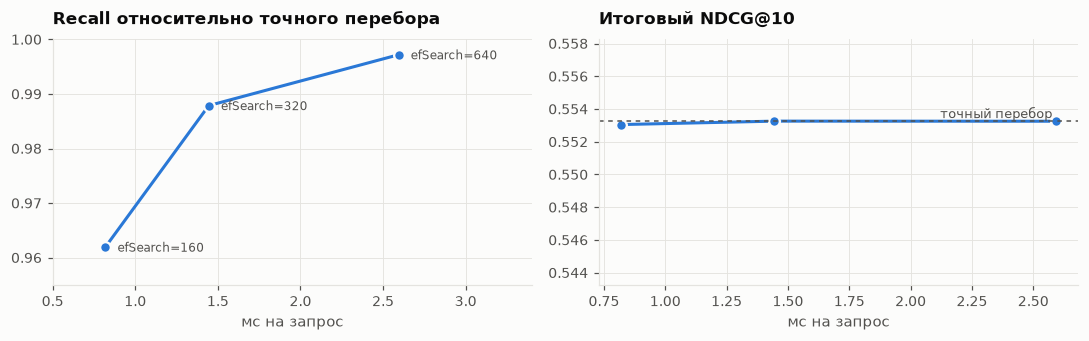

In [29]:
ann = load("ann")
df_ann = pd.DataFrame(ann["grid"])
display(df_ann.round(4))
print(f"корпус: {ann['corpus_size']:,} векторов размерности {ann['dim']}, "
      f"индекс построен за {ann['build_seconds']:.1f} с")
print(f"точный перебор: {ann['exact_batched_ms']:.2f} мс/запрос батчем на ускорителе, "
      f"{ann['exact_single_ms']:.2f} мс/запрос по одному на CPU")

exact_ndcg = RESULTS[ann["tag"]]["test"]["NDCG@10"]
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(df_ann["ms_per_query"], df_ann["recall_vs_exact"], marker="o", color=BLUE,
           markeredgecolor=SURFACE, markeredgewidth=1.5)
for _, r in df_ann.iterrows():
    ax[0].annotate(f"efSearch={int(r['efSearch'])}", (r["ms_per_query"], r["recall_vs_exact"]),
                   fontsize=8, color=INK_2, xytext=(8, -3), textcoords="offset points", ha="left")
ax[0].set_xlim(0.5, 3.4); ax[0].set_ylim(0.955, 1.0)
ax[0].set_xlabel("мс на запрос"); ax[0].set_title("Recall относительно точного перебора")
ax[1].plot(df_ann["ms_per_query"], df_ann["NDCG@10"], marker="o", color=BLUE,
           markeredgecolor=SURFACE, markeredgewidth=1.5)
ax[1].axhline(exact_ndcg, color=INK_2, ls=(0, (3, 3)), lw=1)
ax[1].text(df_ann["ms_per_query"].max(), exact_ndcg, "точный перебор ", color=INK_2,
           fontsize=8.5, ha="right", va="bottom")
ax[1].set_ylim(exact_ndcg - 0.01, exact_ndcg + 0.005)
ax[1].set_xlabel("мс на запрос"); ax[1].set_title("Итоговый NDCG@10")
plt.tight_layout(); save(fig, "ann"); plt.show()

На 150 тысячах документов точный перебор батчем на ускорителе (0.33 мс на запрос) быстрее
индекса; по одному запросу на CPU — наоборот, 7.2 мс против 0.8 мс у HNSW. Главное же в
другом: при настройке, теряющей 4% ближайших соседей, итоговое качество не меняется вообще —
0.5530 против 0.5533. Теряются документы с хвоста, до которых пользователю нет дела. Значит,
на большом корпусе за скорость можно платить точностью индекса почти безнаказанно.

## 8. LLM-судья

Второй вопрос проекта: может ли языковая модель размечать данные вместо человека.
Модели-судьи сейчас используют часто, а насколько их оценки совпадают с оценками живого
асессора, измеряют редко.

Зачем это нужно. Для обучения нужны пары «запрос — документ» с меткой, метки ставит
человек, поэтому их всегда мало. Судья, которому можно верить, дал бы три вещи:

- **исправил бы ошибки в обучающих данных.** Негативы подбираются автоматически, и часть
  из них на самом деле правильные ответы (пример — статья про Освальда из раздела 4).
  4% подобранных документов человек прямо отметил как релевантные, но ещё 80% не смотрел
  никто;
- **разметил бы пары, которых в MIRACL нет;**
- **увеличил бы объём данных:** 50 верхних документов для каждого из 4683 обучающих
  запросов — это 234 тысячи пар вместо 10 тысяч.

Если оценки судьи с человеческими не совпадут, ничего из этого сделать нельзя. Это тоже
полноценный ответ: вопрос стоял «можно ли доверять», и отрицательный ответ с числом на
руках не хуже положительного.

Судья — `qwen2.5:7b` в квантовании Q4_K_M через локальный Ollama: веса хранятся примерно
в 4 битах вместо 16, модель занимает 4.7 ГБ и влезает в ноутбук ценой небольшой потери
качества. Детерминизм — `temperature=0`, фиксированный seed, ответ по JSON-схеме. Рубрика
на четыре градации: бинарный вопрос заставлял бы модель в пограничных случаях решать
наугад, а границу между «да» и «нет» подбираем потом, по согласию с людьми.

Проверка — на 600 парах из valid-запросов: 300 релевантных и 300 проверенно
нерелевантных (те самые близкие по теме документы, которые асессор забраковал).

In [30]:
RUBRIC = """0 — не относится к вопросу: другая тема или другой объект.
1 — та же тема, но ответа на вопрос нет: упоминается тот же объект, однако
    искомого факта в тексте не найти.
2 — ответ есть частично: можно извлечь часть искомого факта или ответ дан
    неявно, через смежные сведения.
3 — прямой ответ: в тексте явно есть тот факт, который спрашивают."""

PROMPT_V1 = """Ты оцениваешь релевантность текста поисковому запросу.

Шкала:
{rubric}

Запрос: {query}

Текст: {passage}

Оценка:"""

# Версия 2 написана после разбора ошибок первой (ниже), под две найденные закономерности:
# путаница объектов и требование дословности.
PROMPT_V2 = """Ты — асессор поисковой выдачи. Реши, содержит ли ТЕКСТ ответ на ВОПРОС.

Шкала:
{rubric}

Порядок рассуждения — строго такой:

ШАГ 1. Определи, о каком именно объекте спрашивают: конкретный город, человек,
здание, организация, произведение, событие. Выпиши его для себя.

ШАГ 2. Проверь, что ТЕКСТ про ЭТОТ ЖЕ объект. Это главное правило.
Похожее название — не то же самое: Калуга и Калуш разные города, Ватикан и
Ватиканский архив разные объекты, Останкинская башня и другая башня в Москве
разные сооружения. Если текст про другой объект, оценка 0 — даже если в нём
есть фраза, которая по форме выглядит ответом на вопрос.

ШАГ 3. Только если объект тот же — проверь, есть ли искомый факт.
Ответ засчитывается, даже если он сформулирован не теми словами и подан
неявно, но однозначно следует из написанного. Требовать дословную
формулировку не надо.

ШАГ 4. Поставь оценку:
   3 — тот же объект, искомый факт есть (явно или однозначно следует);
   2 — тот же объект, факт есть частично или ответ неполный;
   1 — тот же объект, но искомого факта нет;
   0 — текст про другой объект.

ВОПРОС: {query}

ТЕКСТ: {passage}

Оценка:"""

PROMPTS = {"v1": PROMPT_V1, "v2": PROMPT_V2}


def build_prompt(query, passage, version, max_chars=1800):
    return (PROMPTS[version].format(rubric=RUBRIC, query=query, passage=passage[:max_chars])
            + '\nВерни только JSON вида {"grade": <число>}.')


print(build_prompt("<запрос>", "<пассаж>", "v1"))

Ты оцениваешь релевантность текста поисковому запросу.

Шкала:
0 — не относится к вопросу: другая тема или другой объект.
1 — та же тема, но ответа на вопрос нет: упоминается тот же объект, однако
    искомого факта в тексте не найти.
2 — ответ есть частично: можно извлечь часть искомого факта или ответ дан
    неявно, через смежные сведения.
3 — прямой ответ: в тексте явно есть тот факт, который спрашивают.

Запрос: <запрос>

Текст: <пассаж>

Оценка:
Верни только JSON вида {"grade": <число>}.


Первая версия намеренно голая: сначала надо посмотреть, где судья ошибается сам по
себе, и только потом чинить промпт по фактам.

Accuracy обманчива — судья, всегда отвечающий «релевантен», получит 50% на
сбалансированной выборке. Основная метрика — **каппа Коэна** $(p_o - p_e)/(1 - p_e)$,
где $p_o$ — доля совпадений, а $p_e$ — доля, которая вышла бы у двух независимых
разметчиков с теми же частотами ответов. То есть каппа вычитает случайное согласие:
0.4–0.6 умеренное, 0.6–0.8 существенное, выше 0.8 почти идеальное.

In [31]:
def cohen_kappa(a, b):
    labels, n = sorted(set(a) | set(b)), len(a)
    p_o = sum(x == y for x, y in zip(a, b)) / n
    p_e = sum((a.count(l) / n) * (b.count(l) / n) for l in labels)
    return (p_o - p_e) / (1 - p_e) if p_e != 1 else 0.0


# полное согласие -> 1, согласие только по случайности -> около 0
print("совпали полностью:", round(cohen_kappa([1, 0, 1, 0], [1, 0, 1, 0]), 3))
print("угадывание:       ", round(cohen_kappa([1, 0, 1, 0], [1, 1, 0, 0]), 3))

совпали полностью: 1.0
угадывание:        0.0


In [32]:
OLLAMA, JUDGE_MODEL = "http://localhost:11434", "qwen2.5:7b"
GRADE_SCHEMA = {"type": "object", "required": ["grade"],
                "properties": {"grade": {"type": "integer", "enum": [0, 1, 2, 3]}}}


def judge_eval_pairs(split="valid", n_pos=300, n_neg=300, seed=SEED):
    """Сбалансированная выборка пар «запрос — пассаж» с человеческой меткой."""
    pos, neg = [], []
    for q in SP[f"{split}_qids"]:
        for d, r in QRELS_DEV.get(q, {}).items():
            if d in BY_ID:
                (pos if r > 0 else neg).append({"qid": q, "docid": d, "human": int(r > 0)})
    rng = random.Random(seed)
    rng.shuffle(pos); rng.shuffle(neg)
    out = pos[:n_pos] + neg[:n_neg]
    rng.shuffle(out)
    return out


def call_judge(prompt, retries=3):
    """Оценка 0–3 от локальной модели и время ответа в секундах."""
    import requests
    body = {"model": JUDGE_MODEL, "prompt": prompt, "stream": False, "format": GRADE_SCHEMA,
            "options": {"temperature": 0, "seed": SEED, "num_predict": 24}}
    for attempt in range(retries):
        t0 = time.time()
        try:
            r = requests.post(f"{OLLAMA}/api/generate", json=body, timeout=180)
            r.raise_for_status()
            return json.loads(r.json()["response"])["grade"], time.time() - t0
        except Exception:
            time.sleep(1.5 * (attempt + 1))
    return None, None


if RUN_JUDGE:
    pairs = judge_eval_pairs()
    for p in pairs:
        p["passage_len"] = len(BY_ID[p["docid"]])
        for version in PROMPTS:
            p[f"grade_{version}"], p[f"sec_{version}"] = call_judge(
                build_prompt(TOPICS[p["qid"]], BY_ID[p["docid"]], version))
    dump({"model": JUDGE_MODEL, "split": "valid", "pairs": pairs}, "judge_valid")

In [33]:
JV = pd.DataFrame(load("judge_valid")["pairs"])


def agreement(human, pred):
    human, pred = list(human), list(pred)
    tp = sum(h == 1 and p == 1 for h, p in zip(human, pred))
    fp = sum(h == 0 and p == 1 for h, p in zip(human, pred))
    fn = sum(h == 1 and p == 0 for h, p in zip(human, pred))
    prec, rec = tp / (tp + fp), tp / (tp + fn)
    return {"каппа": cohen_kappa(human, pred), "accuracy": np.mean(np.array(human) == np.array(pred)),
            "precision": prec, "recall": rec, "F1": 2 * prec * rec / (prec + rec),
            "ложно релевантных": fp, "пропусков": fn}


rows = []
for version in PROMPTS:
    for t in (1, 2, 3):
        rows.append({"промпт": version, "граница «релевантен»": f"оценка ≥ {t}",
                     **agreement(JV["human"], (JV[f"grade_{version}"] >= t).astype(int))})
AGREE = pd.DataFrame(rows).round(3)
display(AGREE)
print(f"средняя задержка: {JV['sec_v1'].mean():.2f} с на пару (v1), {JV['sec_v2'].mean():.2f} с (v2)")

,промпт,граница «релевантен»,каппа,accuracy,precision,recall,F1,ложно релевантных,пропусков
0,v1,оценка ≥ 1,0.390,0.695,0.630,0.947,0.756,167,16
1,v1,оценка ≥ 2,0.480,0.740,0.767,0.690,0.726,63,93
2,v1,оценка ≥ 3,0.270,0.635,0.829,0.340,0.482,21,198
3,v2,оценка ≥ 1,0.513,0.757,0.742,0.787,0.764,82,64
4,v2,оценка ≥ 2,0.360,0.680,0.838,0.447,0.583,26,166
5,v2,оценка ≥ 3,0.287,0.643,0.841,0.353,0.498,20,194


средняя задержка: 3.13 с на пару (v1), 1.88 с (v2)


Лучшая граница для первой версии — «оценка ≥ 2», каппа **0.48**: умеренное согласие.
Разбор ошибок дал две закономерности, и обе не те, что ожидались.

**Ложные срабатывания — путаница объектов:** судья находит фразу, которая *по форме*
отвечает на вопрос, и не проверяет, про тот ли она объект.

| запрос | что подсунуто | почему судья купился |
|---|---|---|
| день города в **Калуге** | статья про **Калуш** | «отмечает день города в 3-ю субботу сентября» |
| высота **Останкинской** башни | другая московская башня | «Высота башни — 258 метров» |
| когда основан **Ватикан** | **Ватиканский секретный архив** | «официально основан в 1610» |

**Пропуски — требование дословности:** «Принимал ли КВ-85 участие в боевых действиях?»
при тексте «свою задачу КВ-85 в основном выполнял». А длина пассажа, на которую
подозрение падало заранее, ни при чём:

In [34]:
v1_pred = (JV["grade_v1"] >= 2).astype(int)
by_len = pd.cut(JV["passage_len"], [0, 300, 800, 10**6], labels=["< 300", "300–800", "> 800"],
                right=False)
display(pd.DataFrame({"пар": JV.groupby(by_len, observed=True).size(),
                      "точность судьи v1": (v1_pred == JV["human"]).groupby(by_len, observed=True).mean()}).round(3))

print("распределение оценок судьи:")
pd.DataFrame({v: JV[f"grade_{v}"].value_counts().sort_index() for v in PROMPTS}).T

,пар,точность судьи v1
passage_len,,
< 300,56,0.768
300–800,309,0.725
> 800,235,0.753


распределение оценок судьи:


,0,1,2,3
v1,149,181,147,123
v2,282,158,34,126


Вторая версия промпта (текст ниже) переписана под найденное: проверка объекта перед
проверкой факта, запрет засчитывать похожие названия, разрешение неявных ответов. Каппа
выросла с **0.480 до 0.513** — прибавка есть, но скромная: судья так и остался в зоне
«умеренное согласие».

Интереснее, что поехало распределение оценок. Пошаговая проверка объекта сделала судью
решительным: оценка 2 («ответ есть частично») почти исчезла, зато ноль стал вдвое
частотнее. Документы про другой объект теперь отсекаются сразу, а не размазываются по
середине шкалы. Побочный эффект: лучшая граница сместилась с «≥ 2» на «≥ 1» — в v2
единица означает «объект тот же», и это само по себе неплохо предсказывает человеческую
метку.

In [35]:
print(build_prompt("<запрос>", "<пассаж>", "v2"))

Ты — асессор поисковой выдачи. Реши, содержит ли ТЕКСТ ответ на ВОПРОС.

Шкала:
0 — не относится к вопросу: другая тема или другой объект.
1 — та же тема, но ответа на вопрос нет: упоминается тот же объект, однако
    искомого факта в тексте не найти.
2 — ответ есть частично: можно извлечь часть искомого факта или ответ дан
    неявно, через смежные сведения.
3 — прямой ответ: в тексте явно есть тот факт, который спрашивают.

Порядок рассуждения — строго такой:

ШАГ 1. Определи, о каком именно объекте спрашивают: конкретный город, человек,
здание, организация, произведение, событие. Выпиши его для себя.

ШАГ 2. Проверь, что ТЕКСТ про ЭТОТ ЖЕ объект. Это главное правило.
Похожее название — не то же самое: Калуга и Калуш разные города, Ватикан и
Ватиканский архив разные объекты, Останкинская башня и другая башня в Москве
разные сооружения. Если текст про другой объект, оценка 0 — даже если в нём
есть фраза, которая по форме выглядит ответом на вопрос.

ШАГ 3. Только если объект тот же — 

**Вывод по второму вопросу проекта осторожный:** судья такого размера пока не годится на
замену асессору. Каппа 0.5 на сбалансированной выборке — это примерно каждая четвёртая
метка мимо, а обучаться на таком — значит закладывать ошибку в модель. Промпт правится по
матрице ошибок, и это работает, но до уровня, на котором ему можно отдать разметку, судья
не дотянул. Версия-победитель на test не прогонялась: раз на valid планка не взята,
финальный замер ничего бы не решил.

## 9. Итоговая таблица

Все строки — один и тот же мини-корпус и одни и те же 947 тестовых запросов.

,подход,Recall@10,Recall@100,NDCG@10,MRR@10
0,BM25,0.6504,0.8558,0.5142,0.5400
1,"rubert-tiny2, без дообучения",0.1796,0.4577,0.1335,0.1615
2,"дообучен, негативы только из батча (батч 64)",0.6699,0.8887,0.5369,0.5903
3,дообучен + сложные негативы (батч 64),0.6869,0.8898,0.5533,0.6063
4,"дообучен, батч 256, lr 1.6e-4",0.7039,0.9072,0.5592,0.6031
5,"дообучен, негативы с позиций 16–30",0.6991,0.8954,0.5603,0.6094
6,"multilingual-e5-small, без дообучения",0.8835,0.9941,0.7595,0.7905


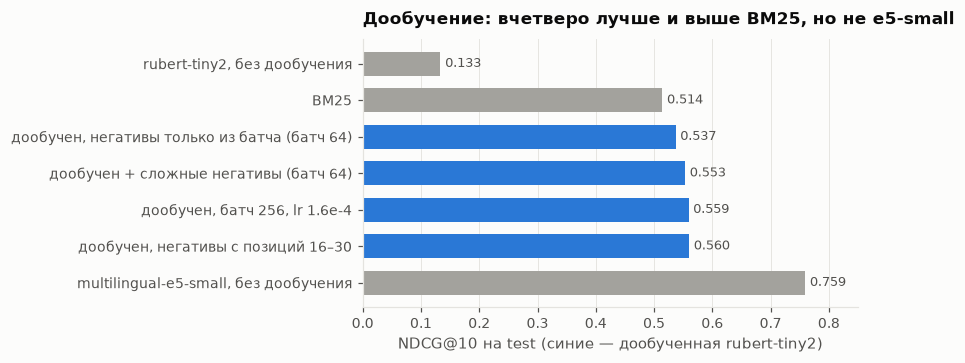

,A,B,ΔNDCG@10 (B − A),95% интервал,вывод
0,BM25,"дообучен, негативы с позиций 16–30",0.0460,"[+0.0211, +0.0702]",значимо
1,"дообучен, негативы с позиций 16–30","multilingual-e5-small, без дообучения",0.1992,"[+0.1807, +0.2183]",значимо


In [36]:
FINAL = ["bm25", "rubert_tiny2_zs", "ft_inbatch_bs64", "ft_mined_bs64", "ft_inbatch_bs256_lr",
         "ft_band_16_30", "e5_small_zs"]
display(show(FINAL))

order = ["rubert_tiny2_zs", "bm25", "ft_inbatch_bs64", "ft_mined_bs64", "ft_inbatch_bs256_lr",
         "ft_band_16_30", "e5_small_zs"]
vals = [RESULTS[t]["test"]["NDCG@10"] for t in order]
colors = [BLUE if t.startswith("ft_") else "#a3a29d" for t in order]
fig, ax = plt.subplots(figsize=(8, 3.4))
bars = ax.barh([RESULTS[t]["label"] for t in order][::-1], vals[::-1], color=colors[::-1], height=0.66)
for b_, v in zip(bars, vals[::-1]):
    ax.text(v + 0.008, b_.get_y() + b_.get_height() / 2, f"{v:.3f}", va="center",
            fontsize=8.5, color=INK_2)
ax.set_xlim(0, 0.85); ax.grid(axis="y", visible=False)
ax.set_xlabel("NDCG@10 на test (синие — дообученная rubert-tiny2)")
ax.set_title("Дообучение: вчетверо лучше и выше BM25, но не e5-small")
plt.tight_layout(); save(fig, "results"); plt.show()
pd.DataFrame([compare("bm25", "ft_band_16_30"), compare("ft_band_16_30", "e5_small_zs")])

## 10. Разбор ошибок

Средние числа скрывают, что именно ломается. Смотрим на лучшую дообученную модель
(негативы с позиций 16–30) по отдельным запросам.

запросов: 947
  полный провал (NDCG@10 = 0):    116 (12.2%)
  идеальная выдача (NDCG@10 = 1): 131 (13.8%)


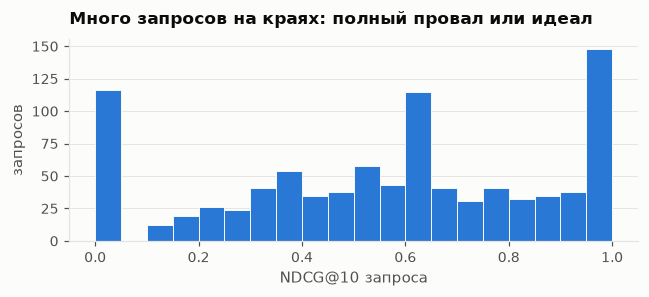

In [37]:
BEST = "ft_band_16_30"
vals = np.array(list(PQ["ndcg@10"][BEST].values()))
print(f"запросов: {len(vals)}")
print(f"  полный провал (NDCG@10 = 0):    {int((vals == 0).sum())} ({(vals == 0).mean():.1%})")
print(f"  идеальная выдача (NDCG@10 = 1): {int((vals == 1).sum())} ({(vals == 1).mean():.1%})")

fig, ax = plt.subplots(figsize=(6, 2.8))
ax.hist(vals, bins=20, range=(0, 1), color=BLUE, edgecolor=SURFACE, linewidth=0.6)
ax.grid(axis="x", visible=False)
ax.set_xlabel("NDCG@10 запроса"); ax.set_ylabel("запросов")
ax.set_title("Много запросов на краях: полный провал или идеал")
plt.tight_layout(); plt.show()

У распределения тяжёлые края: примерно на каждом восьмом запросе модель не находит ничего,
примерно на каждом седьмом выдача идеальная. Значит, средний NDCG сам по себе мало о чём
говорит — смотреть надо, чем отличаются эти группы. Грубый срез — по типу вопроса
(первому слову):

In [38]:
qt = pd.Series(PQ["query_type"])
nd = pd.Series(PQ["ndcg@10"][BEST])
by_type = pd.DataFrame({"запросов": nd.groupby(qt).size(), "NDCG@10": nd.groupby(qt).mean()})
by_type[by_type["запросов"] >= 15].sort_values("NDCG@10").round(4)

,запросов,NDCG@10
что,25,0.3699
как называется,32,0.4286
какой,77,0.4659
кто (человек),93,0.5276
как (способ),49,0.5499
прочее,307,0.5714
сколько (число),99,0.5986
когда (дата),200,0.5997
где (место),43,0.6406


Хуже всего вопросы, где ответ — название или определение («что», «как называется»,
«какой»): у них меньше опорных слов, которые можно сопоставить с текстом. Лучше всего —
«где», «сколько» и «когда»: в запросе обычно есть конкретная сущность, а ответ — дата,
число или место прямо в том же абзаце.

## 11. Выводы

**Дообучение под домен окупается.** Десять тысяч пар поднимают `rubert-tiny2` с уровня
«в разы хуже BM25» (0.133) до уверенно выше него (0.560 против 0.514 — разница значима
по бутстрепу), а одно обучение занимает несколько минут. Дорого стоит разметка, а не
вычисления — поэтому вопрос про судью не праздный.

**Что именно двигает качество.** Негативы из батча при батче 64 дают только уровень BM25.
Дальше работают два рычага: число негативов внутри батча (с lr, масштабированным вместе
с батчем) и сложные негативы — причём **средней** трудности: слишком трудные, включая
проверенные человеком, обучают хуже.

**Но дообучение не заменяет предобучение.** `multilingual-e5-small` без всякого
дообучения остаётся далеко впереди (0.759). Вывод не «дообучение не помогает», а
«маленькая модель на десяти тысячах примеров не догоняет модель, которую учили под
поиск на сотнях миллионов пар». Для исходной бытовой задачи это значит простое: брать
сильную готовую модель и доучивать её, а не тянуть маленькую с нуля.

**Второй этаж поиска.** HNSW теряет только нерелевантный хвост — на большом корпусе им
можно пользоваться почти бесплатно. Кросс-энкодер на
трёхслойной модели не обучается совсем; та же постановка на 12-слойной e5-small учится.

**Судье пока рано доверять разметку:** каппа 0.48 → 0.51 после правки промпта по
матрице ошибок — умеренное согласие, не больше.

### Что осталось незакрытым

- реранкер на `e5-small` поверх выдачи и сравнение трёх лоссов ранжирования — проверка
  показала, что он учится, но до замера на выдаче дело не дошло;
- большой батч вместе со сложными негативами не влез в 16 ГБ; на машине с памятью
  побольше это первый эксперимент;
- судья не прогонялся на test, а его дистилляция в маленький кросс-энкодер не
  запускалась — она упирается в ту же ёмкость, что и реранкер;
- дообучать `e5-small` вместо `rubert-tiny2`, перемайнивать негативы выдачей уже
  дообученной модели (как в ANCE), учить на скорах учителя (MarginMSE), а не на
  бинарных метках. **[ОЦЕНКА]** Переход e5-small → e5-base даёт по таблице E5 +0.024
  NDCG@10 на полном MIRACL-ru — это часы кодирования корпуса ради предсказуемого вывода.

## Приложение: сводка по гипотезам

| гипотеза | итог | чем кончилось |
|---|---|---|
| урезание корпуса в 64 раза сильно облегчает задачу | подтвердилась | BM25 даёт NDCG@10 0.514 против 0.334 на полном корпусе |
| дообучение под домен сильно обходит zero-shot | подтвердилась | 0.133 → 0.537 только на негативах из батча, до 0.560 с лучшими негативами |
| сложные негативы дают прирост поверх негативов из батча | подтвердилась | +0.016 NDCG@10 при батче 64, значимо |
| больший батч в MNRL — больше негативов и лучше качество | подтвердилась после починки эксперимента | при фиксированном lr выходило наоборот; с масштабированным lr 0.510 → 0.537 → 0.543 → 0.550 → 0.559 для батчей 16 / 64 / 96 / 128 / 256 |
| человеческие негативы лучше подобранных автоматически, ведь среди них нет ложных | **опровергнута** | 0.501 против 0.540; человеческие оказались труднее (в топ-10 73% против 58%) |
| трудность негатива имеет оптимум | подтвердилась | 0.551 → 0.560 → 0.550 для полос 6–15 / 16–30 / 31–50 |
| кросс-энкодер на rubert-tiny2 переставит топ-50 точнее | **опровергнута** | не обучился; причина — ёмкость: e5-small в той же постановке учится |
| правка промпта по матрице ошибок поднимает согласие судьи | подтвердилась, но слабо | каппа 0.480 → 0.513 |

## Приложение: где пришлось повозиться с железом

**Кеш аллокатора MPS распухает на обучении.** Шаг вырос с 0.4 секунды до 14, машина ушла
в своп. `sentence-transformers` паддит батч по самой длинной строке в нём, форма тензора
меняется почти каждый шаг, а аллокатор MPS резервирует блоки под каждую новую форму —
кеш набрал 13 ГБ. Лечится `torch.mps.empty_cache()` раз в 10–25 шагов. Диагностику это
уводит не туда: `ps` MPS-аллокации не показывает, память выглядит как «wired без
владельца».

**Матрица внимания весит `batch × heads × L² × 4` байта** — при батче 256 и длине 512 это
3.2 ГБ на один батч. Отсюда длина 256: она покрывает 90% пассажей целиком и снимает
проблему.